In [3]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

import torch

if torch.cuda.is_available():
    device = torch.device("cuda")

In [ ]:
import os
import yaml
import ray
from ray import tune
from ray.tune.schedulers import ASHAScheduler
from ray.tune.search.optuna import OptunaSearch
from ray.air import session
from ultralytics import YOLO
import json

ROOT = os.getcwd()

ray.shutdown()
ray.init(_temp_dir=os.path.join("/home/xkozak6/tmp","tmp"), num_gpus=2)

os.environ["YOLO_VERBOSE"] = "false"

def train_yolo(config):
    model = YOLO("yolo11l.pt")
    
    results = model.train(
        data=os.path.join(ROOT,"ctc_merged_dataset/data.yaml"),
        
        epochs=75,
        imgsz=640,
        patience=20,
        device=-1,
        
        batch=16,
        lr0=config["lr0"],
        lrf=0.01,
        momentum=config["momentum"],
        weight_decay=config["weight_decay"],
        
        degrees=config["degrees"],
        translate=config["translate"],
        scale=config["scale"],
        flipud=config["flipud"],
        fliplr=config["fliplr"],
        hsv_v=config["hsv_v"],
        erasing=0.0,
        
        mosaic=config["mosaic"],
        mixup=0.0,
        copy_paste=0.0,
        close_mosaic=0,
        hsv_h=0.0,
        hsv_s=0.0,
        
        optimizer="AdamW",
        warmup_epochs=3,
        warmup_bias_lr=0.1,
        warmup_momentum=0.8,
    
        project= os.path.join(ROOT,"ray/all_data_run"),
        save=False,
        pretrained=True,
        plots=False,
        verbose=False,  
        save_period=-1
    )

    metrics = model.metrics  
    box = metrics.box        
    
    tune.report({
        "metrics/mAP50-95(B)": box.map,        
        "metrics/mAP50(B)": box.map50,         
        "metrics/precision(B)": box.mp,        
        "metrics/recall(B)": box.mr,           
    })

    
search_space = {
    "degrees": tune.uniform(0.0, 45.0),
    "translate":  tune.uniform(0.0, 0.5),
    "scale": tune.uniform(0.0, 0.5),
    "hsv_v": tune.uniform(0.0, 0.5),
    
    "mosaic": tune.uniform(0.0, 1.0),
    "flipud": tune.uniform(0.0, 1.0),
    "fliplr": tune.uniform(0.0, 1.0),
    
    "lr0": tune.loguniform(0.0001, 0.003),
    "weight_decay": tune.loguniform(0.0001, 0.001),
    "momentum": tune.uniform(0.85, 0.98),
}

scheduler = ASHAScheduler(
    max_t=75,  
    grace_period=10, 
    reduction_factor=3, 
)

search_alg = OptunaSearch(
    metric="metrics/mAP50-95(B)",
    mode="max",
)

print("Starting Ray Tune hyperparameter optimization...")
print(f"Total trials: 100")
print(f"Max epochs per trial: 50")
print(f"Early stopping: Enabled (grace period: 10 epochs)")
print("="*80)

tuner = tune.Tuner(
    tune.with_resources(
        train_yolo,
        resources={"gpu": 1}
    ),
    param_space=search_space,
    tune_config=tune.TuneConfig(
        metric="metrics/mAP50-95(B)",
        mode="max",
        scheduler=scheduler,
        search_alg=search_alg,
        num_samples=100,  # number of trials
        max_concurrent_trials=2,  # adjust based on your GPU availability
    ),
    run_config=tune.RunConfig(
        name="ray_tune_hyperparam_search_phc_small_cells_ctc_merged_dataset",
        verbose=1,               # 0: no table, 1: table only, 2: full logs
        log_to_file=False,        # or ("stdout.log", "stderr.log")
        # local_dir="path/to/ray_results",   # optional
    ),
)

results = tuner.fit()

best_result = results.get_best_result(metric="metrics/mAP50-95(B)", mode="max")
bm = best_result.metrics

print(f"Best mAP50-95: {bm['metrics/mAP50-95(B)']:.4f}")

print("\n" + "="*80)
print("BEST HYPERPARAMETERS FOUND:")
print("="*80)
print(f"Best mAP50-95: {best_result.metrics['metrics/mAP50-95(B)']:.4f}")
print(f"Best mAP50: {best_result.metrics['metrics/mAP50(B)']:.4f}")
print(f"Best Precision: {best_result.metrics['metrics/precision(B)']:.4f}")
print(f"Best Recall: {best_result.metrics['metrics/recall(B)']:.4f}")
print("\nHyperparameters:")
for key, value in best_result.config.items():
    print(f"  {key}: {value}")
print("="*80)

output_dir = os.path.join(ROOT, "all_data/ray_tune_hyperparam_search_phc_small_cells_ctc_merged_dataset/")
os.makedirs(output_dir, exist_ok=True)
best_config_path = os.path.join(output_dir, "best_hyperparameters.yaml")

best_config = {
    "metrics": best_result.metrics,
    "hyperparameters": dict(best_result.config)
}

with open(best_config_path, 'w') as f:
    json.dump(best_config, f, indent=4)

print(f"\nBest configuration saved to: {best_config_path}")
print(f"\nTo train with best hyperparameters:")
print(f"python train_best.py --config {best_config_path}")

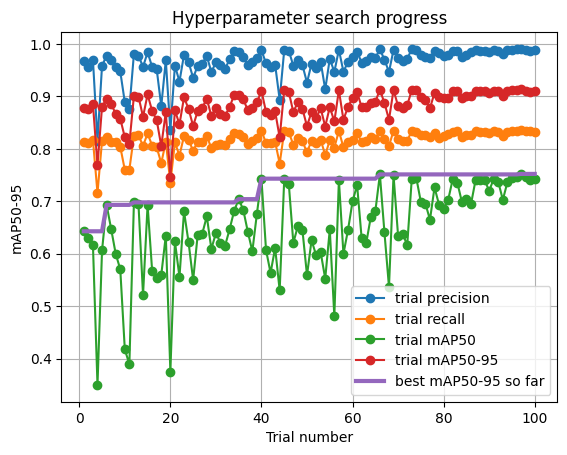

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

df = results.get_dataframe()

df = df.sort_values("time_total_s").reset_index(drop=True)

df["trial_number"] = df.index + 1

df["best_mAP50_95_so_far"] = df["metrics/mAP50-95(B)"].cummax()


plt.figure()
plt.plot(df["trial_number"], df["metrics/precision(B)"], marker="o", label="trial precision")

plt.plot(df["trial_number"], df["metrics/recall(B)"], marker="o", label="trial recall")

plt.plot(df["trial_number"], df["metrics/mAP50-95(B)"], marker="o", label="trial mAP50")
plt.plot(df["trial_number"], df["metrics/mAP50(B)"], marker="o", label="trial mAP50-95")
plt.plot(df["trial_number"], df["best_mAP50_95_so_far"], linewidth=3, label="best mAP50-95 so far")
plt.xlabel("Trial number")
plt.ylabel("mAP50-95")
plt.title("Hyperparameter search progress")
plt.legend()
plt.grid(True)
plt.savefig("plots/ray_tune_hyperparam_search_phc_small_cells_ctc_merged_dataset.png")  
plt.show()
